In [ ]:
import os
import random
from itertools import product

import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace, asdict
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

import pandas as pd

In [ ]:
@dataclass
class Config:
    image_size: tuple = (128, 128)
    batch_size: int = 32
    epochs: int = 15
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    train_split: float = 0.8
    seed: int = 42
    num_workers: int = 2
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    pin_memory: bool = torch.cuda.is_available()

    base_channels: int = 64
    use_batchnorm: bool = True
    dropout: float = 0.1
    model_name: str = "unet_bn_dropout"


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


config = Config()
set_seed(config.seed)

In [ ]:
print(torch.__version__)
print(torch.version.cuda)

2.11.0+cu128
12.8


In [ ]:
class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()

        layers = []

        for conv_in, conv_out in [
            (in_channels, out_channels),
            (out_channels, out_channels),
        ]:
            layers.append(nn.Conv2d(conv_in, conv_out, kernel_size=3, padding=1))

            if use_batchnorm:
                layers.append(nn.BatchNorm2d(conv_out))

            layers.append(nn.ReLU(inplace=True))

        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=64,
        dropout=0.0,
        use_batchnorm=False,
    ):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8
        c5 = base_channels * 16

        # Encoder
        self.enc1 = DoubleConv(in_channels, c1, dropout, use_batchnorm)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(c1, c2, dropout, use_batchnorm)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(c2, c3, dropout, use_batchnorm)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(c3, c4, dropout, use_batchnorm)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(c4, c5, dropout, use_batchnorm)

        # Decoder
        self.up4 = nn.ConvTranspose2d(c5, c4, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(c5, c4, dropout, use_batchnorm)

        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c4, c3, dropout, use_batchnorm)

        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c3, c2, dropout, use_batchnorm)

        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c2, c1, dropout, use_batchnorm)

        self.final = nn.Conv2d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # Bottleneck
        b = self.bottleneck(p4)

        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None, image_size=(128, 128)):
        self.root = root
        self.transform = transform
        self.image_size = image_size

        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True,
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        mask = np.array(mask)

        mask = (mask == 1).astype(np.uint8)
        mask = Image.fromarray(mask).resize(
            self.image_size,
            resample=Image.Resampling.NEAREST,
        )

        if self.transform:
            image = self.transform(image)

        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (
            2. * intersection + self.smooth
        ) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

In [ ]:
class Trainer:
    def __init__(self, config):
        self.config = config
        set_seed(config.seed)

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5],
            ),
        ])

        self.model = UNet(
            base_channels=config.base_channels,
            dropout=config.dropout,
            use_batchnorm=config.use_batchnorm,
        ).to(config.device)

        self.criterion = BCEDiceLoss()

        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )

        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='max',
            factor=0.5,
            patience=2,
        )

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_iou': [],
            'val_f1': [],
        }

        self.test_metrics = None
        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(
            root="./data",
            split='trainval',
            transform=self.transform,
            image_size=self.config.image_size,
        )

        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size
        split_generator = torch.Generator().manual_seed(self.config.seed)

        train_dataset, val_dataset = random_split(
            dataset,
            [train_size, val_size],
            generator=split_generator,
        )

        self.test_dataset = PetDataset(
            root="./data",
            split='test',
            transform=self.transform,
            image_size=self.config.image_size,
        )

        loader_generator = torch.Generator().manual_seed(self.config.seed)

        self.train_dataloader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
            generator=loader_generator,
        )

        self.val_dataloader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )

        self.test_dataloader = DataLoader(
            self.test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )

    def run(self, run_test=True):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.scheduler.step(val_iou)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(
                f"Epoch {epoch + 1} / {self.config.epochs}, "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val IoU: {val_iou:.4f}, "
                f"Val F1-score: {val_f1:.4f}"
            )

        if run_test:
            test_loss, test_iou, test_f1 = self.test()

            self.test_metrics = {
                'test_loss': test_loss,
                'test_iou': test_iou,
                'test_f1': test_f1,
            }

            print(
                f"Test Loss: {test_loss:.4f}, "
                f"Test IoU: {test_iou:.4f}, "
                f"Test F1-score: {test_f1:.4f}"
            )

        return self.test_metrics

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device, non_blocking=True)
            masks = masks.to(self.config.device, non_blocking=True)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def _compute_metrics(self, outputs, masks):
        pred_masks = (
            torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5
        ).astype(np.uint8)

        true_masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

        iou_scores = []
        f1_scores_list = []

        for i in range(len(pred_masks)):
            iou_scores.append(
                jaccard_score(
                    true_masks[i].flatten(),
                    pred_masks[i].flatten(),
                    average='binary',
                    zero_division=0,
                )
            )

            f1_scores_list.append(
                f1_score(
                    true_masks[i].flatten(),
                    pred_masks[i].flatten(),
                    average='binary',
                    zero_division=0,
                )
            )

        return iou_scores, f1_scores_list

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores = []
        f1_scores_list = []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device, non_blocking=True)
                masks = masks.to(self.config.device, non_blocking=True)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                batch_iou, batch_f1 = self._compute_metrics(outputs, masks)
                iou_scores.extend(batch_iou)
                f1_scores_list.extend(batch_f1)

        return (
            val_loss / len(self.val_dataloader),
            np.mean(iou_scores),
            np.mean(f1_scores_list),
        )

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores = []
        f1_scores_list = []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device, non_blocking=True)
                masks = masks.to(self.config.device, non_blocking=True)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                batch_iou, batch_f1 = self._compute_metrics(outputs, masks)
                iou_scores.extend(batch_iou)
                f1_scores_list.extend(batch_f1)

        return (
            test_loss / len(self.test_dataloader),
            np.mean(iou_scores),
            np.mean(f1_scores_list),
        )

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(
                n_samples,
                3,
                figsize=(10, 3 * n_samples),
            )

            if n_samples == 1:
                axes = np.expand_dims(axes, axis=0)

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype(float)

                image_for_plot = (img.permute(1, 2, 0).cpu() * 0.5 + 0.5).clamp(0, 1)

                axes[i, 0].imshow(image_for_plot)
                axes[i, 0].set_title("Image")

                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")

                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

                for ax in axes[i]:
                    ax.axis('off')

            plt.tight_layout()
            plt.show()

In [ ]:
trainer = Trainer(config)

100%|██████████| 792M/792M [00:29<00:00, 26.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.15MB/s]


In [ ]:
trainer.run()

100%|██████████| 23/23 [00:09<00:00,  2.35it/s]


Epoch 1 / 15, Train Loss: 0.9436, Val Loss: 0.7989, Val IoU: 0.5675, Val F1-score: 0.7082


100%|██████████| 23/23 [00:09<00:00,  2.32it/s]


Epoch 2 / 15, Train Loss: 0.7418, Val Loss: 0.6720, Val IoU: 0.6120, Val F1-score: 0.7423


100%|██████████| 23/23 [00:09<00:00,  2.30it/s]


...

100%|██████████| 23/23 [00:09<00:00,  2.32it/s]


Epoch 15 / 15, Train Loss: 0.2921, Val Loss: 0.3482, Val IoU: 0.7747, Val F1-score: 0.8635
Testing...


100%|██████████| 115/115 [00:47<00:00,  2.44it/s]

Test Loss: 0.3591, Test IoU: 0.7681, Test F1-score: 0.8577


{'test_loss': 0.3591001002684883,
 'test_iou': np.float64(0.7680938033509698),
 'test_f1': np.float64(0.857662497679124)}

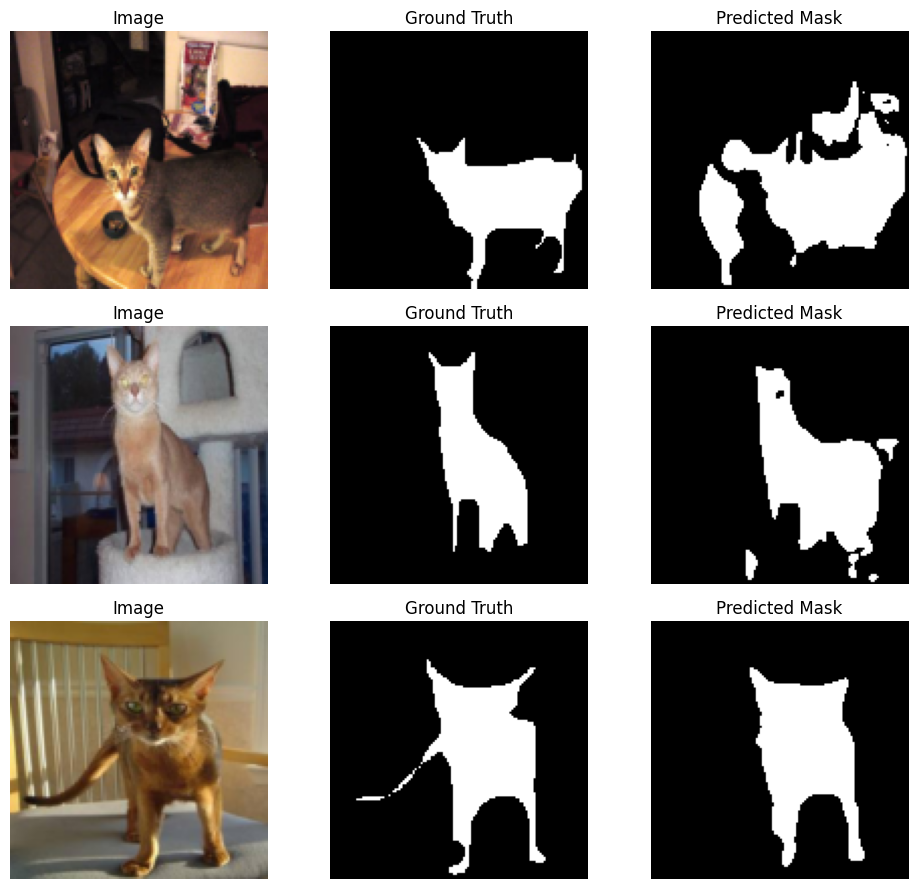

In [ ]:
trainer.inference_and_plot_samples(n_samples=3)

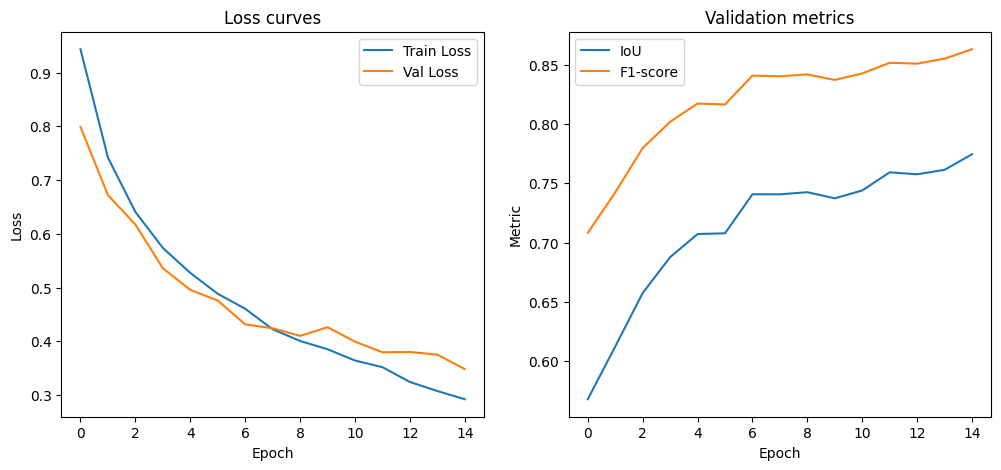

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trainer.history['train_loss'], label='Train Loss')
plt.plot(trainer.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(trainer.history['val_iou'], label='IoU')
plt.plot(trainer.history['val_f1'], label='F1-score')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.legend()
plt.title('Validation metrics')

plt.show()

In [ ]:
results = []
hyperparameter_histories = {}

learning_rates = [1e-3, 1e-4, 1e-5]
batch_sizes = [16, 32, 64]

for lr, bs in product(learning_rates, batch_sizes):
    print(f'Experiment: lr={lr}, batch_size={bs}')

    experiment_config = replace(
        config,
        learning_rate=lr,
        batch_size=bs,
        epochs=5
    )

    trainer = Trainer(experiment_config)
    trainer.run(run_test=False)

    results.append({
        'lr': lr,
        'batch_size': bs,
        'best_val_IoU': max(trainer.history['val_iou']),
        'final_val_IoU': trainer.history['val_iou'][-1],
        'best_val_F1': max(trainer.history['val_f1']),
        'final_val_F1': trainer.history['val_f1'][-1],
        'final_val_loss': trainer.history['val_loss'][-1],
    })

    hyperparameter_histories[(lr, bs)] = trainer.history

Experiment: lr=0.001, batch_size=16


100%|██████████| 46/46 [00:09<00:00,  4.66it/s]


Epoch 1 / 5, Train Loss: 0.9140, Val Loss: 0.8593, Val IoU: 0.5141, Val F1-score: 0.6646


100%|██████████| 46/46 [00:08<00:00,  5.14it/s]


Epoch 2 / 5, Train Loss: 0.7902, Val Loss: 0.8064, Val IoU: 0.5327, Val F1-score: 0.6794


...

Epoch 3 / 5, Train Loss: 0.9623, Val Loss: 0.8653, Val IoU: 0.5493, Val F1-score: 0.6940


100%|██████████| 12/12 [00:09<00:00,  1.21it/s]


Epoch 4 / 5, Train Loss: 0.8806, Val Loss: 0.8242, Val IoU: 0.5692, Val F1-score: 0.7105


100%|██████████| 12/12 [00:10<00:00,  1.13it/s]

Epoch 5 / 5, Train Loss: 0.8360, Val Loss: 0.7894, Val IoU: 0.5805, Val F1-score: 0.7192


In [ ]:
results_df = pd.DataFrame(results)
results_df

,lr,batch_size,best_val_IoU,final_val_IoU,best_val_F1,final_val_F1,final_val_loss
0,0.00100,16,0.613066,0.524376,0.743211,0.655589,0.730304
1,0.00100,32,0.653112,0.620620,0.777126,0.745882,0.595789
2,0.00100,64,0.658541,0.658541,0.779330,0.779330,0.584650
3,0.00010,16,0.721533,0.721533,0.826740,0.826740,0.441338
4,0.00010,32,0.707151,0.707151,0.817514,0.817514,0.495684
5,0.00010,64,0.681822,0.681822,0.797657,0.797657,0.586714
6,0.00001,16,0.631552,0.631552,0.759540,0.759540,0.686893
7,0.00001,32,0.604170,0.604170,0.737346,0.737346,0.749925
8,0.00001,64,0.580465,0.580465,0.719151,0.719151,0.789411


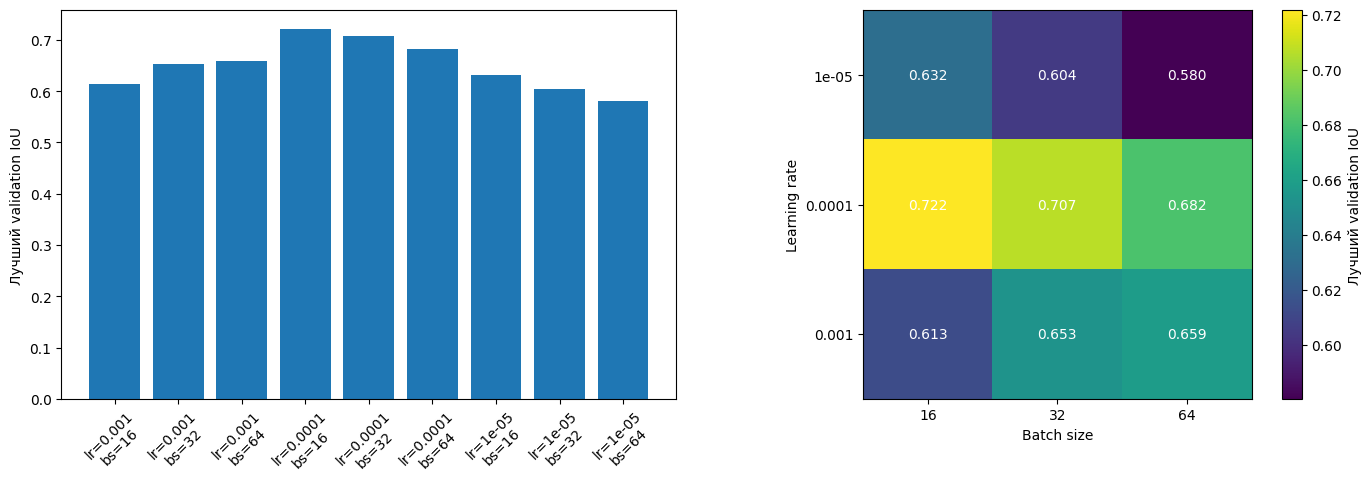

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f"lr={r['lr']}\nbs={r['batch_size']}" for r in results]
ious = [r['best_val_IoU'] for r in results]

axes[0].bar(labels, ious)
axes[0].set_ylabel('Лучший validation IoU')
axes[0].tick_params(axis='x', rotation=45)

pivot = results_df.pivot(index='lr', columns='batch_size', values='best_val_IoU')
im = axes[1].imshow(pivot.values, cmap='viridis')
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_xticklabels(pivot.columns)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index)
axes[1].set_xlabel('Batch size')
axes[1].set_ylabel('Learning rate')

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        axes[1].text(
            j,
            i,
            f'{pivot.values[i, j]:.3f}',
            ha='center',
            va='center',
            color='white',
        )

fig.colorbar(im, ax=axes[1], label='Лучший validation IoU')
plt.tight_layout()
plt.show()